In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassnainzaidi/garbage-classification")

print("Path to dataset files:", path)

100%|██████████| 123M/123M [00:00<00:00, 141MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hassnainzaidi/garbage-classification/versions/1


In [2]:

import tensorflow as tf
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
train_dataset =tf.keras.preprocessing.image_dataset_from_directory(
"/root/.cache/kagglehub/datasets/hassnainzaidi/garbage-classification/versions/1/Garbage classification/train",
image_size=IMG_SIZE,
batch_size=BATCH_SIZE
)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
"/root/.cache/kagglehub/datasets/hassnainzaidi/garbage-classification/versions/1/Garbage classification/val",
image_size=IMG_SIZE,
batch_size=BATCH_SIZE
)
test_dataset =tf.keras.preprocessing.image_dataset_from_directory(
"/root/.cache/kagglehub/datasets/hassnainzaidi/garbage-classification/versions/1/Garbage classification/test",
image_size=IMG_SIZE,
batch_size=BATCH_SIZE,
shuffle=False # Important for evaluation
)
class_names = train_dataset.class_names
print("Classes:", class_names)

Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
model=tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255 ,input_shape=(128,128,3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(6,activation='softmax')
    ])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
model.compile(optimizer='adam',
              loss =tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [5]:
history = model.fit(train_dataset, epochs=5, validation_data=val_dataset)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.3027 - loss: 1.8407 - val_accuracy: 0.4725 - val_loss: 1.4045
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.4780 - loss: 1.3455 - val_accuracy: 0.5378 - val_loss: 1.2239
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.5287 - loss: 1.2002 - val_accuracy: 0.6027 - val_loss: 1.0698
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6154 - loss: 1.0156 - val_accuracy: 0.6731 - val_loss: 0.8924
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.6696 - loss: 0.8948 - val_accuracy: 0.6882 - val_loss: 0.8153


In [6]:
test_loss, test_acc = model.evaluate(train_dataset)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6882 - loss: 0.8153
Test Accuracy: 0.6881678104400635


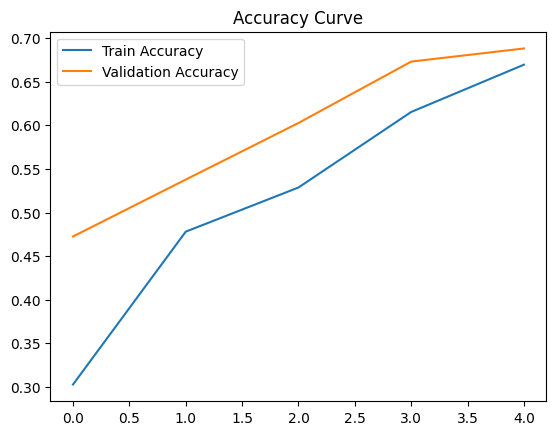

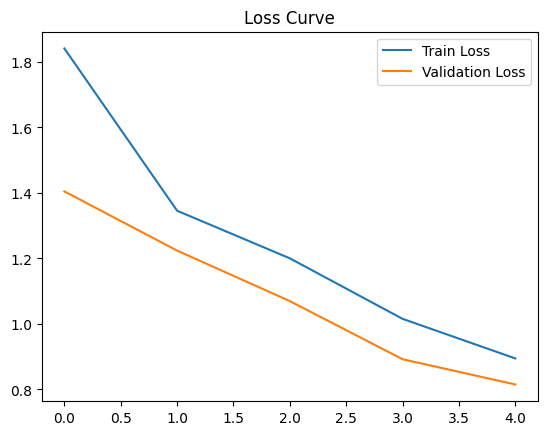

In [7]:
import matplotlib.pyplot as plt
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()
# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()